In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression


In [2]:
data_path = "StudentPerformance/data/Student_performance_data _.csv"
df = pd.read_csv(data_path)
print(df.columns.tolist())


['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [3]:
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df["GradeClass"].value_counts())


   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [4]:
target_col = "GradeClass"
drop_cols = ["StudentID"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())


X shape: (2392, 13)
y shape: (2392,)
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  
0  2.929196  
1  3.042915  
2

In [5]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
print("Target classes:", label_enc.classes_)


Target classes: [0. 1. 2. 3. 4.]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1913, 13)
Test shape: (479, 13)


In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Categorical features: []


In [8]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])


In [9]:
param_grid = {
    "feature_selection__k": [3, 5, 7, 10, "all"],
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "saga"],
    "classifier__penalty": ["l2"]
}


In [10]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV F1 Macro:", grid_search.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best Parameters:
{'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga', 'feature_selection__k': 3}

Best CV F1 Macro: 0.6722875704758344


c:\Users\fjoll\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [11]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)


In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Test Metrics - Logistic Regression:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_enc.classes_]))


Test Metrics - Logistic Regression:
Accuracy: 0.8392
Precision (macro): 0.7543
Recall (macro): 0.6798
F1-score (macro): 0.6937

Classification Report:
              precision    recall  f1-score   support

         0.0       0.57      0.19      0.29        21
         1.0       0.77      0.67      0.71        54
         2.0       0.68      0.87      0.76        78
         3.0       0.83      0.70      0.76        83
         4.0       0.93      0.97      0.95       243

    accuracy                           0.84       479
   macro avg       0.75      0.68      0.69       479
weighted avg       0.84      0.84      0.83       479



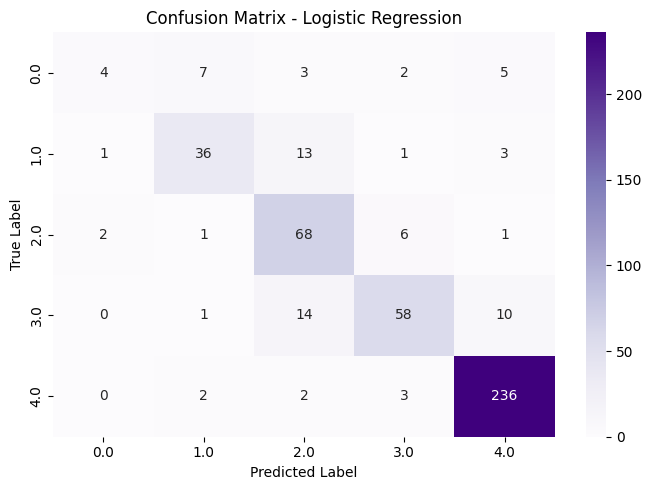

In [13]:
# Confusion matrix and save (Logistic Regression)
try:
    # Ensure predictions available
    if 'y_pred' not in globals():
        if 'grid_search' in globals():
            y_pred = grid_search.best_estimator_.predict(X_test)
        elif 'best_model' in globals():
            y_pred = best_model.predict(X_test)
        else:
            raise NameError('No trained logistic model found. Run training cells first.')
    cm = confusion_matrix(y_test, y_pred)
    os.makedirs("StudentPerformance/visualizations", exist_ok=True)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
    plt.title("Confusion Matrix - Logistic Regression")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("StudentPerformance/visualizations/logistic_regression_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
except Exception as e:
    print('Error creating logistic confusion matrix:', e)


In [14]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Best_Params": [str(grid_search.best_params_)],
    "CV_F1_Macro": [grid_search.best_score_],
    "Test_Accuracy": [accuracy],
    "Test_Precision_Macro": [precision],
    "Test_Recall_Macro": [recall],
    "Test_F1_Macro": [f1]
})
os.makedirs("StudentPerformance/results", exist_ok=True)
results_df.to_csv("StudentPerformance/results/logistic_regression_results.csv", index=False)
print("Results saved to StudentPerformance/results/logistic_regression_results.csv")


Results saved to StudentPerformance/results/logistic_regression_results.csv


In [15]:
# End-to-end Logistic Regression (self-contained)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# load data
data_path = 'StudentPerformance/data/Student_performance_data _.csv'
df = pd.read_csv(data_path)

# prepare
target_col = 'GradeClass'
drop_cols = ['StudentID'] if 'StudentID' in df.columns else []
X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category','bool']).columns.tolist()

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline([('preprocessor', preprocessor), ('feature_selection', SelectKBest(score_func=f_classif, k='all')), ('classifier', LogisticRegression(max_iter=2000, random_state=42))])

param_grid = {
    'feature_selection__k': [3, 5, 7, 'all'],
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['lbfgs'],
    'classifier__penalty': ['l2']
}

gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
print('Fitting Logistic GridSearch...')
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)

best = gs.best_estimator_
y_pred = best.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

# save visualization
os.makedirs('StudentPerformance/visualizations', exist_ok=True)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('StudentPerformance/visualizations/logistic_regression_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# save results
os.makedirs('StudentPerformance/results', exist_ok=True)
results_df = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Best_Params': [str(gs.best_params_)],
    'CV_F1_Macro': [gs.best_score_],
    'Test_Accuracy': [accuracy],
    'Test_Precision_Macro': [precision],
    'Test_Recall_Macro': [recall],
    'Test_F1_Macro': [f1]
})
results_df.to_csv('StudentPerformance/results/logistic_regression_results.csv', index=False)
print('Saved logistic results and visualization')


Fitting Logistic GridSearch...


c:\Users\fjoll\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'feature_selection__k': 3}


Saved logistic results and visualization
